# TC4 钛合金阿伦纽斯（Arrhenius）本构方程计算

基于 Sellars-Tegart 双曲正弦模型：
$$\dot{\varepsilon} = A [\sinh(\alpha \sigma)]^n \exp\left(-\frac{Q}{RT}\right)$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import linregress
import warnings
import re
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120


R_GAS = 8.314  # J/(mol·K)

In [2]:
# ==================== 图片自动高清保存（新增） ====================
import os
import re
from datetime import datetime

NOTEBOOK_DIR = '/Users/bertonyang/project/chenglu/data_processor'
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'arrhenius_calculation_figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 显示清晰度与保存清晰度分离：显示维持原设置，保存统一高清
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.12

_PLOT_TAG = None

def set_plot_tag(tag: str):
    """可选：在绘图前手动设置标签，让文件名更明确。"""
    global _PLOT_TAG
    _PLOT_TAG = str(tag)


def _safe_name(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r'[\\/:*?"<>|\n\r\t]+', '_', text)
    text = re.sub(r'\s+', '_', text)
    text = re.sub(r'_+', '_', text).strip('_')
    if not text:
        text = 'unnamed_figure'
    return text[:160] if len(text) > 160 else text


def _fig_desc(fig) -> str:
    # 优先：手动标签 > suptitle > 前几个子图标题
    global _PLOT_TAG
    if _PLOT_TAG:
        desc = _PLOT_TAG
        _PLOT_TAG = None
        return _safe_name(desc)

    if getattr(fig, '_suptitle', None) is not None:
        st = fig._suptitle.get_text()
        if st and st.strip():
            return _safe_name(st)

    titles = []
    for ax in fig.axes:
        t = ax.get_title()
        if t and t.strip():
            titles.append(t.strip())
    if titles:
        return _safe_name('__'.join(titles[:3]))

    return 'UnnamedFigure'


# 仅 patch 一次，避免重复包装
if not hasattr(plt, '_original_show_for_auto_save'):
    plt._original_show_for_auto_save = plt.show


def _auto_save_and_show(*args, **kwargs):
    fig_nums = plt.get_fignums()
    ipy = globals().get('get_ipython', lambda: None)()
    exec_count = getattr(ipy, 'execution_count', None)
    exec_part = f'cell{exec_count}' if exec_count is not None else 'cellNA'
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')

    for idx, num in enumerate(fig_nums, start=1):
        fig = plt.figure(num)
        desc = _fig_desc(fig)
        filename = f'{exec_part}__fig{idx:02d}__{desc}__{ts}.png'
        out_path = os.path.join(OUTPUT_DIR, filename)
        fig.savefig(out_path, dpi=600, bbox_inches='tight', pad_inches=0.12, facecolor='white')
        print(f'✓ 已自动保存高清图片: {out_path}')

    return plt._original_show_for_auto_save(*args, **kwargs)


plt.show = _auto_save_and_show
print(f', : {OUTPUT_DIR}')
print('命名规则: cell序号__fig序号__图标题(或手动tag)__时间戳.png')
print('可选用法: 在绘图前调用 set_plot_tag("章节_图用途")，可获得更精确文件名')

图片自动保存已启用，输出目录: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures
命名规则: cell序号__fig序号__图标题(或手动tag)__时间戳.png
可选用法: 在绘图前调用 set_plot_tag("章节_图用途")，可获得更精确文件名


## 1. 数据加载与清洗

从原始 Excel 文件正确读取数据（每个 sheet 为一个温度，每两列为一组应变-应力数据对）

In [3]:
file_path = '/Users/bertonyang/project/chenglu/data/TC4_0219.xlsx'
xlsx = pd.ExcelFile(file_path)

all_data = []
for sheet_name in xlsx.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    temp = int(sheet_name)
    num_pairs = df.shape[1] // 2
    for i in range(num_pairs):
        strain_rate = float(df.iloc[0, i * 2])
        col_strain = i * 2
        col_stress = i * 2 + 1
        strain = pd.to_numeric(df.iloc[1:, col_strain], errors='coerce')
        stress = pd.to_numeric(df.iloc[1:, col_stress], errors='coerce')
        for s_val, r_val in zip(strain, stress):
            if pd.notna(s_val) and pd.notna(r_val):
                all_data.append({
                    '温度_C': temp,
                    '温度_K': temp + 273.15,
                    '应变速率': strain_rate,
                    '真应变': s_val,
                    '流变应力': r_val
                })

df_all = pd.DataFrame(all_data)

# 过滤掉应力 <= 0 的数据点（物理上无意义）
df_all = df_all[df_all['流变应力'] > 0].copy()
# 过滤掉应变 <= 0 的数据点
df_all = df_all[df_all['真应变'] > 0].copy()

print(f'总数据量: {len(df_all)} 条')
print(f'温度(°C): {sorted(df_all["温度_C"].unique())}')
print(f'应变速率(s⁻¹): {sorted(df_all["应变速率"].unique())}')
print()
print('各条件数据量:')
for temp in sorted(df_all['温度_C'].unique()):
    for sr in sorted(df_all['应变速率'].unique()):
        sub = df_all[(df_all['温度_C'] == temp) & (df_all['应变速率'] == sr)]
        if len(sub) > 0:
            print(f'  T={temp}°C, ε̇={sr} s⁻¹: {len(sub)} 行, '
                  f'应变=[{sub["真应变"].min():.4f}, {sub["真应变"].max():.4f}], '
                  f'应力=[{sub["流变应力"].min():.2f}, {sub["流变应力"].max():.2f}] MPa')

总数据量: 39109 条
温度(°C): [np.int64(800), np.int64(850), np.int64(900), np.int64(950), np.int64(980), np.int64(1010)]
应变速率(s⁻¹): [np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(1.0), np.float64(10.0)]

各条件数据量:
  T=800°C, ε̇=0.001 s⁻¹: 1381 行, 应变=[0.0000, 0.6873], 应力=[2.29, 79.33] MPa
  T=800°C, ε̇=0.01 s⁻¹: 1393 行, 应变=[0.0000, 0.6782], 应力=[3.09, 157.75] MPa
  T=800°C, ε̇=0.1 s⁻¹: 3421 行, 应变=[0.0000, 0.6809], 应力=[2.34, 299.95] MPa
  T=800°C, ε̇=1.0 s⁻¹: 1483 行, 应变=[0.0001, 0.6934], 应力=[1.55, 340.32] MPa
  T=800°C, ε̇=10.0 s⁻¹: 170 行, 应变=[0.0000, 0.6880], 应力=[0.62, 390.93] MPa
  T=850°C, ε̇=0.001 s⁻¹: 3502 行, 应变=[0.0000, 0.7000], 应力=[2.43, 38.85] MPa
  T=850°C, ε̇=0.01 s⁻¹: 1405 行, 应变=[0.0000, 0.7002], 应力=[1.76, 108.05] MPa
  T=850°C, ε̇=0.1 s⁻¹: 1405 行, 应变=[0.0000, 0.6990], 应力=[1.47, 171.41] MPa
  T=850°C, ε̇=1.0 s⁻¹: 1410 行, 应变=[0.0000, 0.6884], 应力=[3.74, 250.48] MPa
  T=850°C, ε̇=10.0 s⁻¹: 148 行, 应变=[0.0003, 0.6850], 应力=[2.57, 269.83] MPa
  T=900°C, ε̇=0.001 s⁻¹: 3508 行,

## 2. 绘制真应力-真应变曲线

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell5__fig01__ε̇_=_0.001_s⁻¹_ε̇_=_0.01_s⁻¹_ε̇_=_0.1_s⁻¹__20260306_005829.png


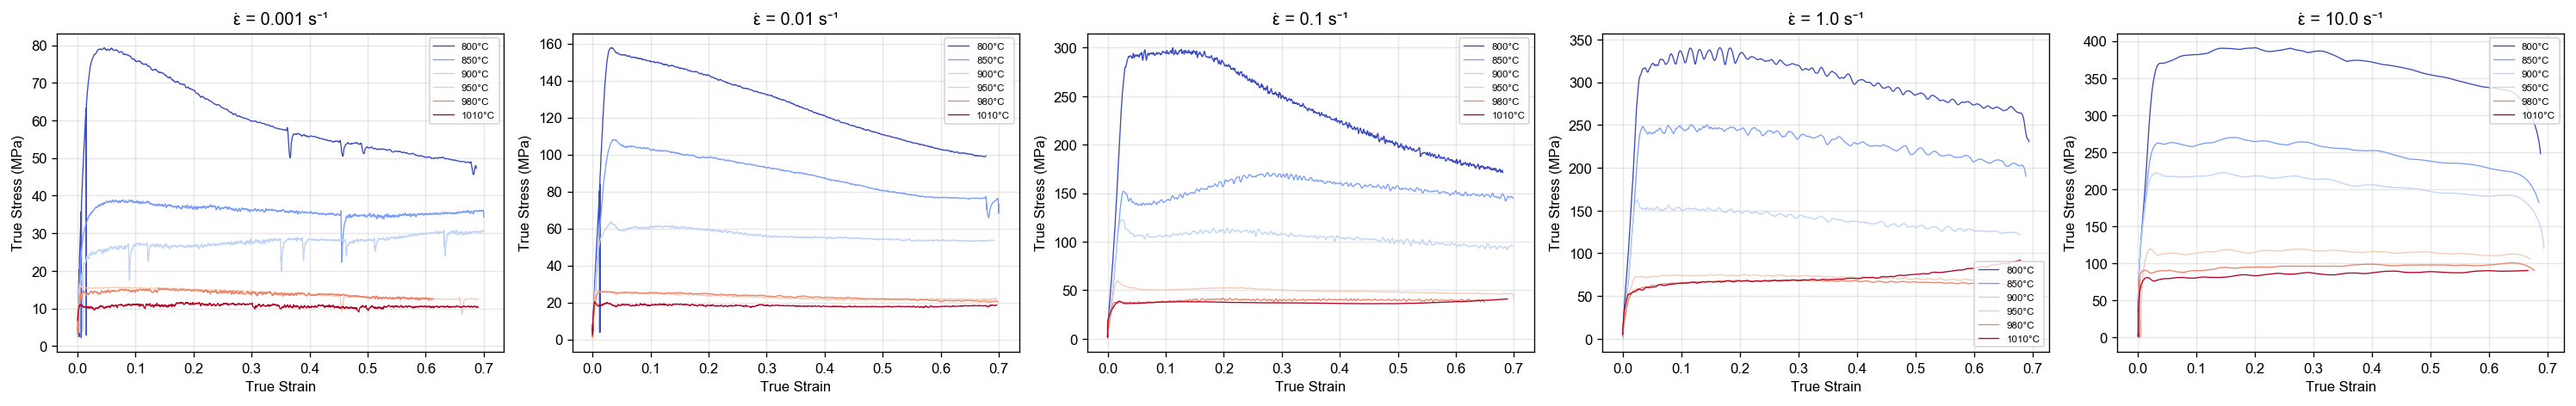

In [4]:
temps = sorted(df_all['温度_C'].unique())
rates = sorted(df_all['应变速率'].unique())
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps)))

fig, axes = plt.subplots(1, len(rates), figsize=(5 * len(rates), 4), sharey=False)
if len(rates) == 1:
    axes = [axes]
for ax, sr in zip(axes, rates):
    for temp, c in zip(temps, colors):
        sub = df_all[(df_all['温度_C'] == temp) & (df_all['应变速率'] == sr)].sort_values('真应变')
        if len(sub) > 0:
            ax.plot(sub['真应变'], sub['流变应力'], color=c, label=f'{temp}°C', linewidth=0.8)
    ax.set_title(f'ε̇ = {sr} s⁻¹')
    ax.set_xlabel('True Strain')
    ax.set_ylabel('True Stress (MPa)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 离散应变点处的应力插值

在每个（温度，应变速率）条件下，对应力-应变曲线进行插值，提取离散应变点处的流变应力值。

In [5]:
strain_points = np.arange(0.05, 0.65, 0.05)
print(f'离散应变点: {strain_points}')
print(f'共 {len(strain_points)} 个应变点')
print()

stress_table = {}
missing_conditions = []

for temp in temps:
    for sr in rates:
        sub = df_all[(df_all['温度_C'] == temp) & (df_all['应变速率'] == sr)].sort_values('真应变')
        if len(sub) < 5:
            missing_conditions.append((temp, sr))
            continue
        # 对数据去重（同一应变值取平均应力）
        sub_grouped = sub.groupby('真应变')['流变应力'].mean().reset_index()
        sub_grouped = sub_grouped.sort_values('真应变')
        try:
            f_interp = interp1d(sub_grouped['真应变'], sub_grouped['流变应力'],
                               kind='linear', fill_value='extrapolate')
            for eps in strain_points:
                if sub_grouped['真应变'].min() <= eps <= sub_grouped['真应变'].max():
                    sigma = float(f_interp(eps))
                    if sigma > 0:
                        stress_table[(temp, sr, eps)] = sigma
        except Exception as e:
            print(f'  插值失败: T={temp}, SR={sr}: {e}')

if missing_conditions:
    print(f'数据不足的条件: {missing_conditions}')

# 构建DataFrame展示
rows = []
for (temp, sr, eps), sigma in stress_table.items():
    rows.append({'温度_C': temp, '温度_K': temp + 273.15, '应变速率': sr, '真应变': eps, '流变应力': sigma})
df_discrete = pd.DataFrame(rows)

print(f'\n插值结果总数: {len(df_discrete)} 条')
print('\n示例数据（ε=0.3 处各条件的流变应力）：')
pivot_sample = df_discrete[df_discrete['真应变'] == 0.3].pivot_table(
    index='温度_C', columns='应变速率', values='流变应力')
print(pivot_sample.round(2))

离散应变点: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6 ]
共 12 个应变点


插值结果总数: 360 条

示例数据（ε=0.3 处各条件的流变应力）：
应变速率  0.001   0.010   0.100   1.000   10.000
温度_C                                        
800    59.84  132.36  249.94  319.63  385.66
850    36.08   92.71  166.74  233.92  260.96
900    27.38   56.31  108.62  143.22  213.52
950    14.55   22.89   50.60   73.40  117.17
980    13.77   23.43   39.09   67.81   96.14
1010   11.14   18.52   36.97   68.37   86.88


## 4. 第一步：求解应力乘子 α

### 4.1 低应力近似 → 求 n₁

$$n_1 = \left( \frac{\partial \ln\dot{\varepsilon}}{\partial \ln\sigma} \right)_T$$

以 ln(σ) 为横坐标，ln(ε̇) 为纵坐标，各温度下拟合直线的平均斜率即为 n₁

In [6]:
n1_results = {}  # {eps: n1_value}
n1_all_slopes = {}  # {eps: {temp: slope}}

for eps in strain_points:
    slopes = {}
    for temp in temps:
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['温度_C'] == temp)]
        if len(sub) >= 2:
            x = np.log(sub['流变应力'].values)
            y = np.log(sub['应变速率'].values)
            slope, intercept, r, p, se = linregress(x, y)
            slopes[temp] = slope
    if slopes:
        n1_results[eps] = np.mean(list(slopes.values()))
        n1_all_slopes[eps] = slopes

print('=== n₁ 计算结果 ===')
print(f'{"应变":>6s} | {"n₁":>10s} | 各温度斜率')
print('-' * 70)
for eps in strain_points:
    if eps in n1_results:
        slope_str = ', '.join([f'{t}°C:{s:.4f}' for t, s in n1_all_slopes[eps].items()])
        print(f'{eps:>6.2f} | {n1_results[eps]:>10.4f} | {slope_str}')

=== n₁ 计算结果 ===
    应变 |         n₁ | 各温度斜率
----------------------------------------------------------------------
  0.05 |     4.6477 | 800°C:5.2764, 850°C:4.4753, 900°C:4.2386, 950°C:4.5389, 980°C:5.0403, 1010°C:4.3169
  0.10 |     4.5970 | 800°C:5.0506, 850°C:4.4307, 900°C:4.3493, 950°C:4.5085, 980°C:4.9465, 1010°C:4.2963
  0.15 |     4.5034 | 800°C:4.8594, 850°C:4.3313, 900°C:4.3052, 950°C:4.3504, 980°C:4.9373, 1010°C:4.2369
  0.20 |     4.4652 | 800°C:4.7480, 850°C:4.2712, 900°C:4.3204, 950°C:4.3801, 980°C:4.8573, 1010°C:4.2144
  0.25 |     4.4111 | 800°C:4.6634, 850°C:4.2395, 900°C:4.3610, 950°C:4.2813, 980°C:4.7571, 1010°C:4.1642
  0.30 |     4.3837 | 800°C:4.5887, 850°C:4.2452, 900°C:4.4147, 950°C:4.2545, 980°C:4.6296, 1010°C:4.1698
  0.35 |     4.3579 | 800°C:4.6033, 850°C:4.2808, 900°C:4.5302, 950°C:4.1721, 980°C:4.6003, 1010°C:3.9604
  0.40 |     4.3559 | 800°C:4.5885, 850°C:4.2706, 900°C:4.5812, 950°C:4.1714, 980°C:4.5511, 1010°C:3.9723
  0.45 |     4.3493 | 800°C:4.5927, 8

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell8__fig01__n₁_Fitting_(ε=0.1)_n₁_Fitting_(ε=0.3)_n₁_Fitting_(ε=0.5)__20260306_005834.png


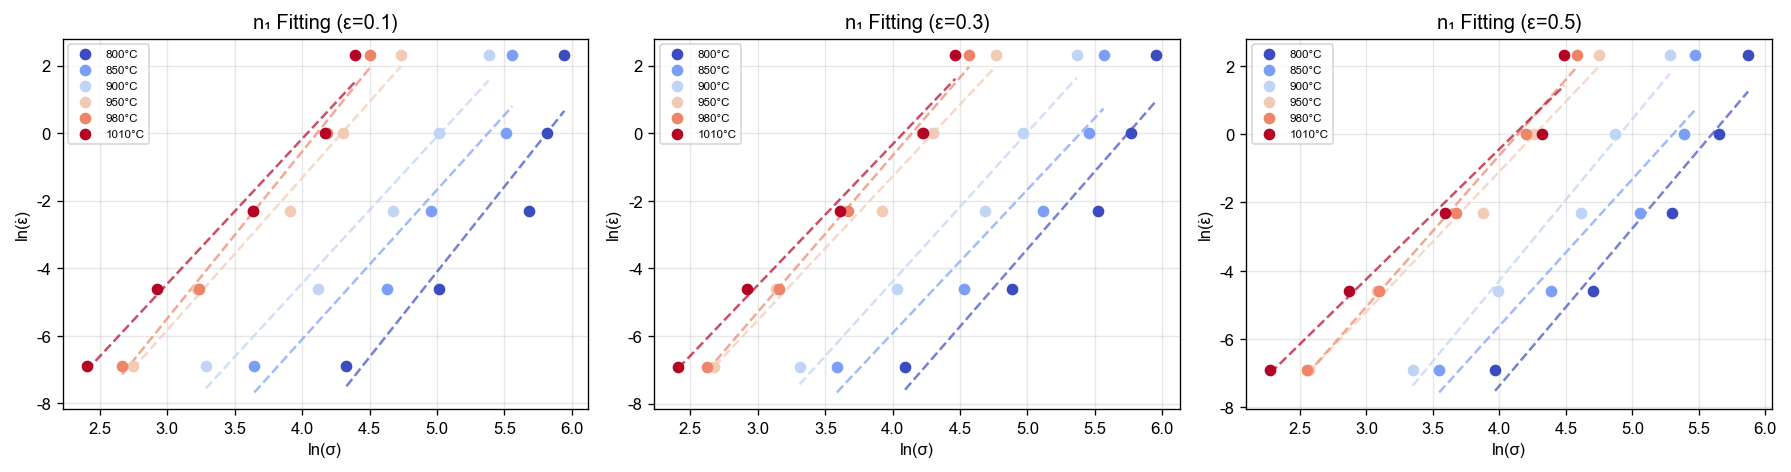

In [7]:
# 可视化 n₁ 拟合（选取几个典型应变点）
sample_strains = [0.1, 0.3, 0.5]
fig, axes = plt.subplots(1, len(sample_strains), figsize=(5 * len(sample_strains), 4))

for ax, eps in zip(axes, sample_strains):
    for temp, c in zip(temps, colors):
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['温度_C'] == temp)]
        if len(sub) >= 2:
            x = np.log(sub['流变应力'].values)
            y = np.log(sub['应变速率'].values)
            ax.scatter(x, y, color=c, label=f'{temp}°C', zorder=5)
            slope, intercept, _, _, _ = linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_fit, slope * x_fit + intercept, '--', color=c, alpha=0.7)
    ax.set_xlabel('ln(σ)')
    ax.set_ylabel('ln(ε̇)')
    ax.set_title(f'n₁ Fitting (ε={eps})')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 高应力近似 → 求 β

$$\beta = \left( \frac{\partial \ln\dot{\varepsilon}}{\partial \sigma} \right)_T$$

以 σ 为横坐标，ln(ε̇) 为纵坐标，各温度下拟合直线的平均斜率即为 β

In [8]:
beta_results = {}
beta_all_slopes = {}

for eps in strain_points:
    slopes = {}
    for temp in temps:
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['温度_C'] == temp)]
        if len(sub) >= 2:
            x = sub['流变应力'].values
            y = np.log(sub['应变速率'].values)
            slope, intercept, r, p, se = linregress(x, y)
            slopes[temp] = slope
    if slopes:
        beta_results[eps] = np.mean(list(slopes.values()))
        beta_all_slopes[eps] = slopes

print('=== β 计算结果 ===')
print(f'{"应变":>6s} | {"β":>10s} | 各温度斜率')
print('-' * 70)
for eps in strain_points:
    if eps in beta_results:
        slope_str = ', '.join([f'{t}°C:{s:.6f}' for t, s in beta_all_slopes[eps].items()])
        print(f'{eps:>6.2f} | {beta_results[eps]:>10.6f} | {slope_str}')

=== β 计算结果 ===
    应变 |          β | 各温度斜率
----------------------------------------------------------------------
  0.05 |   0.074575 | 800°C:0.028890, 850°C:0.038370, 900°C:0.047752, 950°C:0.091134, 980°C:0.116228, 1010°C:0.125074
  0.10 |   0.073272 | 800°C:0.027439, 850°C:0.037693, 900°C:0.048206, 950°C:0.089944, 980°C:0.115535, 1010°C:0.120815
  0.15 |   0.070697 | 800°C:0.026590, 850°C:0.036886, 900°C:0.047057, 950°C:0.085159, 980°C:0.110401, 1010°C:0.118091
  0.20 |   0.070687 | 800°C:0.026608, 850°C:0.037354, 900°C:0.048062, 950°C:0.088336, 980°C:0.109116, 1010°C:0.114646
  0.25 |   0.069420 | 800°C:0.026961, 850°C:0.037643, 900°C:0.048298, 950°C:0.085634, 980°C:0.106218, 1010°C:0.111765
  0.30 |   0.069267 | 800°C:0.027150, 850°C:0.038257, 900°C:0.049110, 950°C:0.085498, 980°C:0.105487, 1010°C:0.110102
  0.35 |   0.069618 | 800°C:0.028031, 850°C:0.039301, 900°C:0.050845, 950°C:0.085241, 980°C:0.105534, 1010°C:0.108755
  0.40 |   0.068952 | 800°C:0.028279, 850°C:0.039287, 900°C:

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell10__fig01__β_Fitting_(ε=0.1)_β_Fitting_(ε=0.3)_β_Fitting_(ε=0.5)__20260306_005837.png


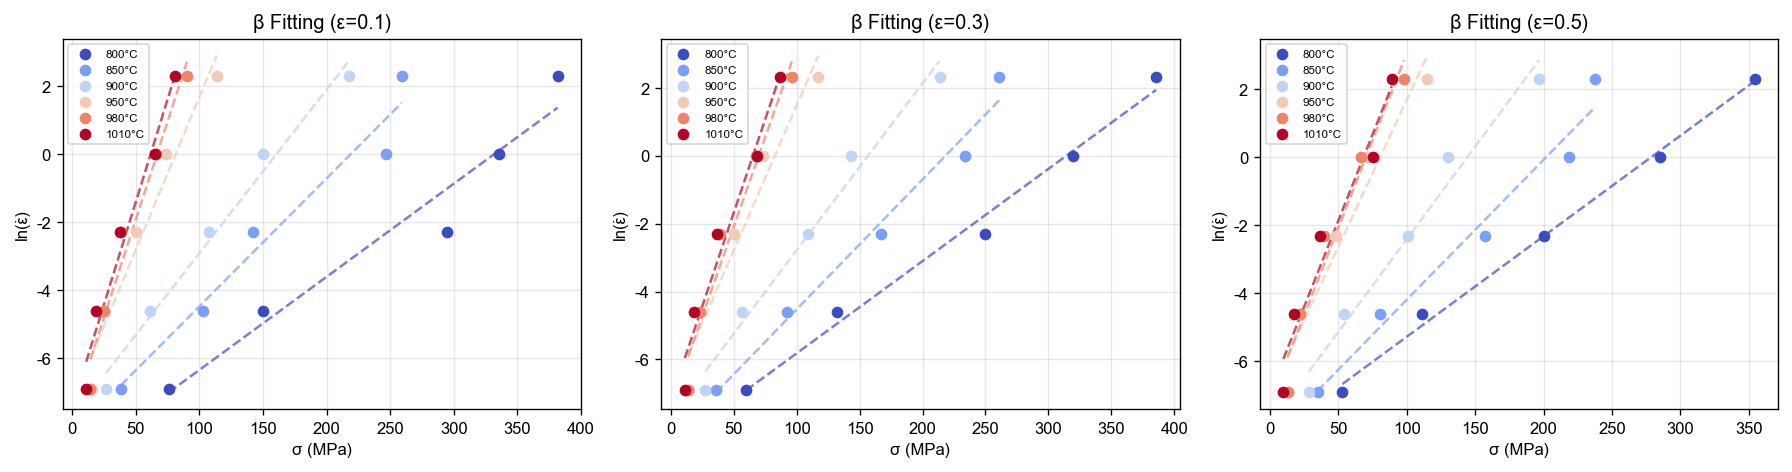

In [9]:
# 可视化 β 拟合
fig, axes = plt.subplots(1, len(sample_strains), figsize=(5 * len(sample_strains), 4))

for ax, eps in zip(axes, sample_strains):
    for temp, c in zip(temps, colors):
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['温度_C'] == temp)]
        if len(sub) >= 2:
            x = sub['流变应力'].values
            y = np.log(sub['应变速率'].values)
            ax.scatter(x, y, color=c, label=f'{temp}°C', zorder=5)
            slope, intercept, _, _, _ = linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_fit, slope * x_fit + intercept, '--', color=c, alpha=0.7)
    ax.set_xlabel('σ (MPa)')
    ax.set_ylabel('ln(ε̇)')
    ax.set_title(f'β Fitting (ε={eps})')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 计算 α = β / n₁

In [10]:
alpha_results = {}
print('=== α 计算结果 ===')
print(f'{"应变":>6s} | {"n₁":>10s} | {"β":>12s} | {"α":>12s}')
print('-' * 50)
for eps in strain_points:
    if eps in n1_results and eps in beta_results:
        alpha = beta_results[eps] / n1_results[eps]
        alpha_results[eps] = alpha
        print(f'{eps:>6.2f} | {n1_results[eps]:>10.4f} | {beta_results[eps]:>12.6f} | {alpha:>12.6f}')

print(f'\nα 平均值: {np.mean(list(alpha_results.values())):.6f}')

=== α 计算结果 ===
    应变 |         n₁ |            β |            α
--------------------------------------------------
  0.05 |     4.6477 |     0.074575 |     0.016045
  0.10 |     4.5970 |     0.073272 |     0.015939
  0.15 |     4.5034 |     0.070697 |     0.015699
  0.20 |     4.4652 |     0.070687 |     0.015831
  0.25 |     4.4111 |     0.069420 |     0.015738
  0.30 |     4.3837 |     0.069267 |     0.015801
  0.35 |     4.3579 |     0.069618 |     0.015975
  0.40 |     4.3559 |     0.068952 |     0.015830
  0.45 |     4.3493 |     0.069406 |     0.015958
  0.50 |     4.3279 |     0.069117 |     0.015970
  0.55 |     4.3704 |     0.069825 |     0.015977
  0.60 |     4.3807 |     0.069861 |     0.015947

α 平均值: 0.015892


## 5. 第二步：求解主应力指数 n

$$n = \left( \frac{\partial \ln\dot{\varepsilon}}{\partial \ln[\sinh(\alpha \sigma)]} \right)_T$$

以 ln[sinh(ασ)] 为横坐标，ln(ε̇) 为纵坐标，不同温度下拟合直线的平均斜率

In [11]:
n_results = {}
n_all_slopes = {}

for eps in strain_points:
    if eps not in alpha_results:
        continue
    alpha = alpha_results[eps]
    slopes = {}
    for temp in temps:
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['温度_C'] == temp)]
        if len(sub) >= 2:
            sigma = sub['流变应力'].values
            x = np.log(np.sinh(alpha * sigma))
            y = np.log(sub['应变速率'].values)
            if np.all(np.isfinite(x)) and np.all(np.isfinite(y)):
                slope, intercept, r, p, se = linregress(x, y)
                slopes[temp] = slope
    if slopes:
        n_results[eps] = np.mean(list(slopes.values()))
        n_all_slopes[eps] = slopes

print('=== n（主应力指数）计算结果 ===')
print(f'{"应变":>6s} | {"n":>10s} | 各温度斜率')
print('-' * 80)
for eps in strain_points:
    if eps in n_results:
        slope_str = ', '.join([f'{t}°C:{s:.4f}' for t, s in n_all_slopes[eps].items()])
        print(f'{eps:>6.2f} | {n_results[eps]:>10.4f} | {slope_str}')

=== n（主应力指数）计算结果 ===
    应变 |          n | 各温度斜率
--------------------------------------------------------------------------------
  0.05 |     3.0763 | 800°C:1.7728, 850°C:2.2163, 900°C:2.5666, 950°C:3.7069, 980°C:4.3113, 1010°C:3.8838
  0.10 |     3.0472 | 800°C:1.6937, 850°C:2.1914, 900°C:2.6192, 950°C:3.6815, 980°C:4.2516, 1010°C:3.8459
  0.15 |     2.9959 | 800°C:1.6627, 850°C:2.1682, 900°C:2.5939, 950°C:3.5440, 980°C:4.2098, 1010°C:3.7967
  0.20 |     2.9860 | 800°C:1.6469, 850°C:2.1682, 900°C:2.6198, 950°C:3.5956, 980°C:4.1355, 1010°C:3.7501
  0.25 |     2.9609 | 800°C:1.6726, 850°C:2.1882, 900°C:2.6486, 950°C:3.5092, 980°C:4.0480, 1010°C:3.6989
  0.30 |     2.9496 | 800°C:1.6736, 850°C:2.2102, 900°C:2.6836, 950°C:3.4875, 980°C:3.9557, 1010°C:3.6872
  0.35 |     2.9288 | 800°C:1.7064, 850°C:2.2432, 900°C:2.7532, 950°C:3.4248, 980°C:3.9250, 1010°C:3.5202
  0.40 |     2.9377 | 800°C:1.7336, 850°C:2.2569, 900°C:2.8036, 950°C:3.4431, 980°C:3.8683, 1010°C:3.5208
  0.45 |     2.9378 | 

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell13__fig01__n_Fitting_(ε=0.1)_n_Fitting_(ε=0.3)_n_Fitting_(ε=0.5)__20260306_005840.png


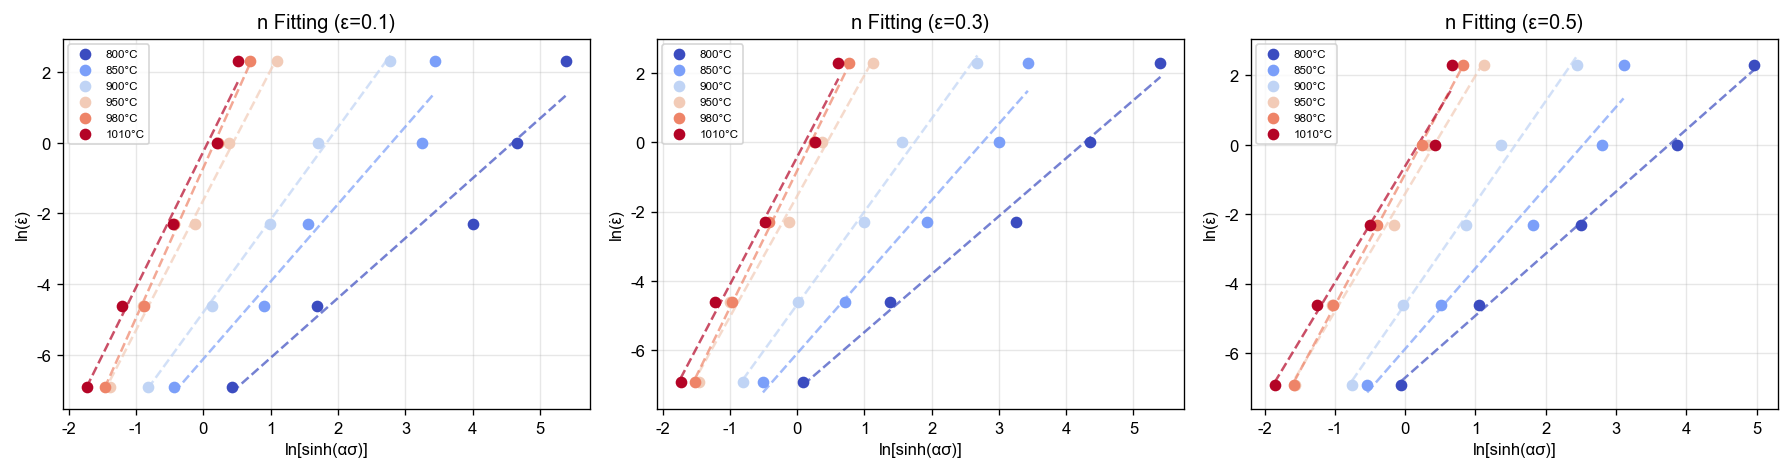

In [12]:
# 可视化 n 拟合
fig, axes = plt.subplots(1, len(sample_strains), figsize=(5 * len(sample_strains), 4))

for ax, eps in zip(axes, sample_strains):
    alpha = alpha_results.get(eps)
    if alpha is None:
        continue
    for temp, c in zip(temps, colors):
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['温度_C'] == temp)]
        if len(sub) >= 2:
            sigma = sub['流变应力'].values
            x = np.log(np.sinh(alpha * sigma))
            y = np.log(sub['应变速率'].values)
            if np.all(np.isfinite(x)):
                ax.scatter(x, y, color=c, label=f'{temp}°C', zorder=5)
                slope, intercept, _, _, _ = linregress(x, y)
                x_fit = np.linspace(x.min(), x.max(), 50)
                ax.plot(x_fit, slope * x_fit + intercept, '--', color=c, alpha=0.7)
    ax.set_xlabel('ln[sinh(ασ)]')
    ax.set_ylabel('ln(ε̇)')
    ax.set_title(f'n Fitting (ε={eps})')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 第三步：求解热变形激活能 Q

$$Q = R \cdot n \cdot \left( \frac{\partial \ln[\sinh(\alpha \sigma)]}{\partial (1/T)} \right)_{\dot{\varepsilon}}$$

以 1/T 为横坐标，ln[sinh(ασ)] 为纵坐标，在相同应变速率下拟合直线的斜率平均值为 S，则 Q = R × n × S

In [13]:
Q_results = {}
S_results = {}  # 斜率 S
S_all_slopes = {}

for eps in strain_points:
    if eps not in alpha_results or eps not in n_results:
        continue
    alpha = alpha_results[eps]
    n_val = n_results[eps]
    slopes = {}
    for sr in rates:
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['应变速率'] == sr)]
        if len(sub) >= 2:
            sigma = sub['流变应力'].values
            T_K = sub['温度_K'].values
            x = 1.0 / T_K  # 1/T
            y = np.log(np.sinh(alpha * sigma))
            if np.all(np.isfinite(x)) and np.all(np.isfinite(y)):
                slope, intercept, r, p, se = linregress(x, y)
                slopes[sr] = slope
    if slopes:
        S_avg = np.mean(list(slopes.values()))
        S_results[eps] = S_avg
        S_all_slopes[eps] = slopes
        Q_results[eps] = R_GAS * n_val * S_avg

print('=== Q（热变形激活能）计算结果 ===')
print(f'{"应变":>6s} | {"n":>8s} | {"S_avg":>12s} | {"Q (J/mol)":>14s} | {"Q (kJ/mol)":>12s}')
print('-' * 70)
for eps in strain_points:
    if eps in Q_results:
        print(f'{eps:>6.2f} | {n_results[eps]:>8.4f} | {S_results[eps]:>12.2f} | {Q_results[eps]:>14.2f} | {Q_results[eps]/1000:>12.2f}')

print()
print('各应变速率下的斜率 S 详情：')
for eps in [0.1, 0.3, 0.5]:
    if eps in S_all_slopes:
        print(f'  ε={eps}: ', ', '.join([f'ε̇={sr}:{s:.2f}' for sr, s in S_all_slopes[eps].items()]))

=== Q（热变形激活能）计算结果 ===
    应变 |        n |        S_avg |      Q (J/mol) |   Q (kJ/mol)
----------------------------------------------------------------------
  0.05 |   3.0763 |     25047.50 |      640621.73 |       640.62
  0.10 |   3.0472 |     25094.03 |      635750.54 |       635.75
  0.15 |   2.9959 |     24789.00 |      617438.15 |       617.44
  0.20 |   2.9860 |     24533.31 |      609057.88 |       609.06
  0.25 |   2.9609 |     23763.08 |      584973.48 |       584.97
  0.30 |   2.9496 |     23239.67 |      569911.92 |       569.91
  0.35 |   2.9288 |     22677.94 |      552206.76 |       552.21
  0.40 |   2.9377 |     21824.39 |      533041.86 |       533.04
  0.45 |   2.9378 |     21275.16 |      519634.55 |       519.63
  0.50 |   2.9295 |     20577.97 |      501197.76 |       501.20
  0.55 |   2.9660 |     19879.13 |      490199.86 |       490.20
  0.60 |   2.9817 |     19191.37 |      475747.46 |       475.75

各应变速率下的斜率 S 详情：
  ε=0.1:  ε̇=0.001:13653.30, ε̇=0.01:19700.67

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell15__fig01__Q_Fitting_(ε=0.1)_Q_Fitting_(ε=0.3)_Q_Fitting_(ε=0.5)__20260306_005843.png


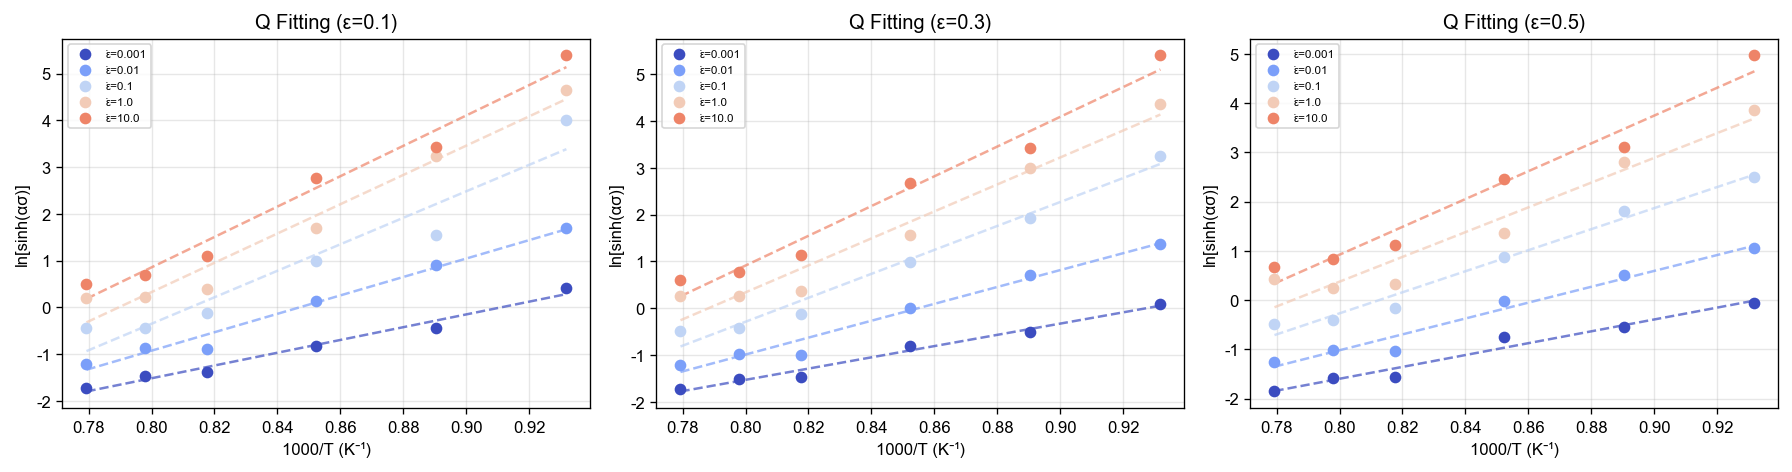

In [14]:
# 可视化 Q 拟合 (ln[sinh(ασ)] vs 1/T)
# rate_colors = plt.cm.viridis(np.linspace(0, 1, len(rates)))
rate_colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps)))
fig, axes = plt.subplots(1, len(sample_strains), figsize=(5 * len(sample_strains), 4))

for ax, eps in zip(axes, sample_strains):
    alpha = alpha_results.get(eps)
    if alpha is None:
        continue
    for sr, c in zip(rates, rate_colors):
        sub = df_discrete[(df_discrete['真应变'] == eps) & (df_discrete['应变速率'] == sr)]
        if len(sub) >= 2:
            sigma = sub['流变应力'].values
            T_K = sub['温度_K'].values
            x = 1.0 / T_K * 1000  # 1000/T for readability
            y = np.log(np.sinh(alpha * sigma))
            if np.all(np.isfinite(y)):
                ax.scatter(x, y, color=c, label=f'ε̇={sr}', zorder=5)
                slope, intercept, _, _, _ = linregress(x, y)
                x_fit = np.linspace(x.min(), x.max(), 50)
                ax.plot(x_fit, slope * x_fit + intercept, '--', color=c, alpha=0.7)
    ax.set_xlabel('1000/T (K⁻¹)')
    ax.set_ylabel('ln[sinh(ασ)]')
    ax.set_title(f'Q Fitting (ε={eps})')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 第四步：求解结构因子 ln A

$$\ln Z = \ln A + n \ln[\sinh(\alpha \sigma)]$$

其中 $Z = \dot{\varepsilon} \exp(Q/RT)$

以 ln[sinh(ασ)] 为横坐标，ln Z 为纵坐标进行全局线性回归，截距即为 ln A

In [15]:
lnA_results = {}
lnA_regression_details = {}

for eps in strain_points:
    if eps not in alpha_results or eps not in n_results or eps not in Q_results:
        continue
    alpha = alpha_results[eps]
    Q_val = Q_results[eps]

    sub = df_discrete[df_discrete['真应变'] == eps].copy()
    if len(sub) < 3:
        continue

    sigma = sub['流变应力'].values
    T_K = sub['温度_K'].values
    sr_vals = sub['应变速率'].values

    ln_Z = np.log(sr_vals) + Q_val / (R_GAS * T_K)
    x = np.log(np.sinh(alpha * sigma))

    valid = np.isfinite(x) & np.isfinite(ln_Z)
    if valid.sum() >= 3:
        slope, intercept, r, p, se = linregress(x[valid], ln_Z[valid])
        lnA_results[eps] = intercept
        lnA_regression_details[eps] = {
            'slope': slope, 'intercept': intercept, 'r_squared': r**2,
            'n_from_regression': slope
        }

print('=== ln A 计算结果 ===')
print(f'{"应变":>6s} | {"ln A":>10s} | {"A":>14s} | {"R²":>8s} | {"回归斜率(≈n)":>12s}')
print('-' * 70)
for eps in strain_points:
    if eps in lnA_results:
        d = lnA_regression_details[eps]
        A_val = np.exp(lnA_results[eps]) if lnA_results[eps] < 700 else float('inf')
        print(f'{eps:>6.2f} | {lnA_results[eps]:>10.4f} | {A_val:>14.4e} | {d["r_squared"]:>8.4f} | {d["slope"]:>12.4f}')

=== ln A 计算结果 ===
    应变 |       ln A |              A |       R² |     回归斜率(≈n)
----------------------------------------------------------------------
  0.05 |    60.5850 |     2.0499e+26 |   0.9343 |       2.7848
  0.10 |    60.1041 |     1.2673e+26 |   0.9273 |       2.7332
  0.15 |    58.2986 |     2.0834e+25 |   0.9277 |       2.6822
  0.20 |    57.4613 |     9.0185e+24 |   0.9276 |       2.6685
  0.25 |    55.1250 |     8.7193e+23 |   0.9323 |       2.6623
  0.30 |    53.6697 |     2.0345e+23 |   0.9336 |       2.6537
  0.35 |    51.9423 |     3.6163e+22 |   0.9386 |       2.6587
  0.40 |    50.1003 |     5.7320e+21 |   0.9397 |       2.6704
  0.45 |    48.7993 |     1.5605e+21 |   0.9389 |       2.6728
  0.50 |    47.0050 |     2.5942e+20 |   0.9431 |       2.6878
  0.55 |    45.9476 |     9.0114e+19 |   0.9419 |       2.7199
  0.60 |    44.5371 |     2.1990e+19 |   0.9423 |       2.7449


✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell17__fig01__ln_A_Fitting_(ε=0.1)_lnA=60.10,_R²=0.9273_ln_A_Fitting_(ε=0.3)_lnA=53.67,_R²=0.9336_ln_A_Fitting_(ε=0.5)_lnA=47.00,_R²=0.9431__20260306_005846.png


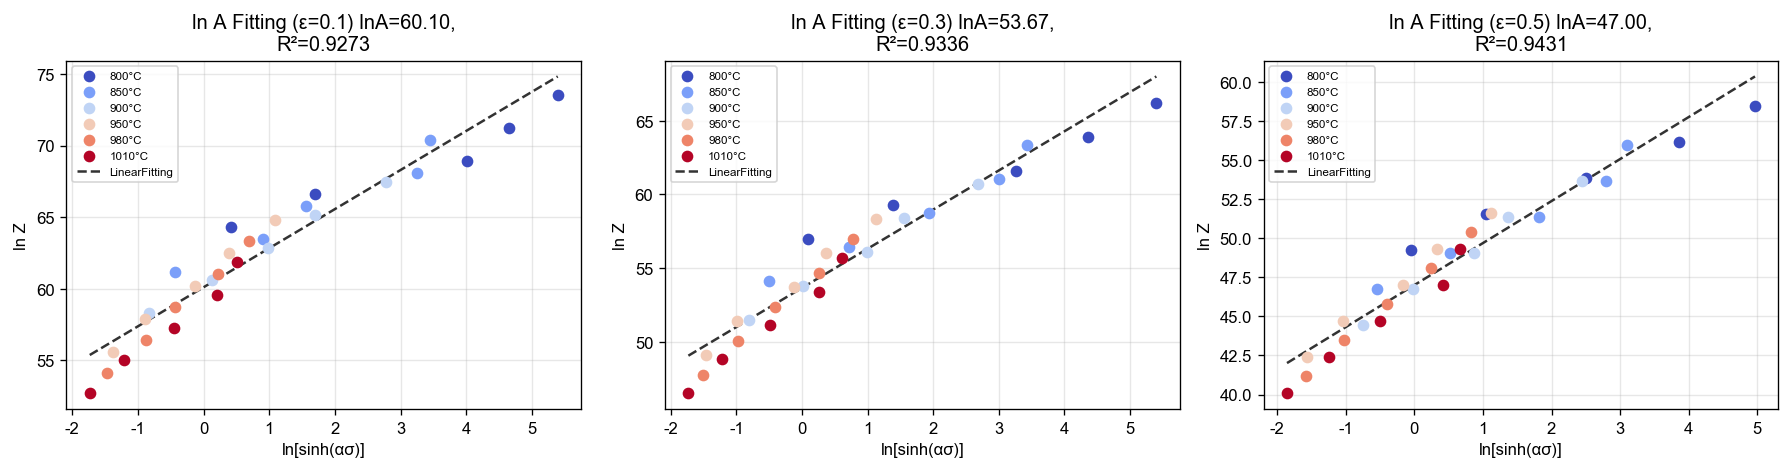

In [16]:
# 可视化 ln A 拟合 (ln Z vs ln[sinh(ασ)])
fig, axes = plt.subplots(1, len(sample_strains), figsize=(5 * len(sample_strains), 4))

for ax, eps in zip(axes, sample_strains):
    alpha = alpha_results.get(eps)
    Q_val = Q_results.get(eps)
    if alpha is None or Q_val is None:
        continue
    sub = df_discrete[df_discrete['真应变'] == eps]
    sigma = sub['流变应力'].values
    T_K = sub['温度_K'].values
    sr_vals = sub['应变速率'].values
    ln_Z = np.log(sr_vals) + Q_val / (R_GAS * T_K)
    x = np.log(np.sinh(alpha * sigma))
    valid = np.isfinite(x) & np.isfinite(ln_Z)

    # 不同温度不同颜色
    for temp, c in zip(temps, colors):
        mask = valid & (sub['温度_C'].values == temp)
        if mask.sum() > 0:
            ax.scatter(x[mask], ln_Z[mask], color=c, label=f'{temp}°C', zorder=5)

    slope, intercept, _, _, _ = linregress(x[valid], ln_Z[valid])
    x_fit = np.linspace(x[valid].min(), x[valid].max(), 50)
    ax.plot(x_fit, slope * x_fit + intercept, 'k--', label=f'线性拟合', alpha=0.8)
    ax.set_xlabel('ln[sinh(ασ)]')
    ax.set_ylabel('ln Z')
    ax.set_title(f'ln A Fitting (ε={eps})\nlnA={intercept:.2f}, R²={linregress(x[valid], ln_Z[valid]).rvalue**2:.4f}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 汇总所有应变点的参数

In [17]:
params_df = pd.DataFrame({
    '真应变': [eps for eps in strain_points if eps in alpha_results and eps in n_results and eps in Q_results and eps in lnA_results],
    'α': [alpha_results[eps] for eps in strain_points if eps in alpha_results and eps in n_results and eps in Q_results and eps in lnA_results],
    'n': [n_results[eps] for eps in strain_points if eps in alpha_results and eps in n_results and eps in Q_results and eps in lnA_results],
    'Q (J/mol)': [Q_results[eps] for eps in strain_points if eps in alpha_results and eps in n_results and eps in Q_results and eps in lnA_results],
    'Q (kJ/mol)': [Q_results[eps]/1000 for eps in strain_points if eps in alpha_results and eps in n_results and eps in Q_results and eps in lnA_results],
    'ln A': [lnA_results[eps] for eps in strain_points if eps in alpha_results and eps in n_results and eps in Q_results and eps in lnA_results],
})

print('=== 所有应变点的 Arrhenius 参数汇总 ===')
print(params_df.to_string(index=False))

=== 所有应变点的 Arrhenius 参数汇总 ===
 真应变        α        n     Q (J/mol)  Q (kJ/mol)      ln A
0.05 0.016045 3.076290 640621.733132  640.621733 60.585026
0.10 0.015939 3.047237 635750.540364  635.750540 60.104112
0.15 0.015699 2.995880 617438.152842  617.438153 58.298642
0.20 0.015831 2.986018 609057.883244  609.057883 57.461321
0.25 0.015738 2.960898 584973.482599  584.973483 55.125001
0.30 0.015801 2.949631 569911.920948  569.911921 53.669708
0.35 0.015975 2.928789 552206.764314  552.206764 51.942332
0.40 0.015830 2.937712 533041.864273  533.041864 50.100343
0.45 0.015958 2.937752 519634.550676  519.634551 48.799317
0.50 0.015970 2.929520 501197.764463  501.197764 47.004966
0.55 0.015977 2.965964 490199.861247  490.199861 45.947608
0.60 0.015947 2.981676 475747.463694  475.747464 44.537100


## 9. 第三章：多项式拟合（参数与应变的连续化）

使用6次多项式拟合 α(ε), n(ε), Q(ε), ln A(ε)

In [18]:
poly_degree = 6
eps_arr = params_df['真应变'].values

# 拟合各参数
poly_alpha = np.polyfit(eps_arr, params_df['α'].values, poly_degree)
poly_n = np.polyfit(eps_arr, params_df['n'].values, poly_degree)
poly_Q = np.polyfit(eps_arr, params_df['Q (J/mol)'].values, poly_degree)
poly_lnA = np.polyfit(eps_arr, params_df['ln A'].values, poly_degree)

print('=== 6次多项式拟合系数 ===')
coeff_labels = [f'x^{i}' for i in range(poly_degree, -1, -1)]

print('\nα(ε) 系数 (B₆ → B₀):')
for label, coeff in zip(coeff_labels, poly_alpha):
    print(f'  {label}: {coeff:.10e}')

print('\nn(ε) 系数 (C₆ → C₀):')
for label, coeff in zip(coeff_labels, poly_n):
    print(f'  {label}: {coeff:.10e}')

print('\nQ(ε) 系数 (D₆ → D₀):')
for label, coeff in zip(coeff_labels, poly_Q):
    print(f'  {label}: {coeff:.10e}')

print('\nln A(ε) 系数 (E₆ → E₀):')
for label, coeff in zip(coeff_labels, poly_lnA):
    print(f'  {label}: {coeff:.10e}')

=== 6次多项式拟合系数 ===

α(ε) 系数 (B₆ → B₀):
  x^6: -1.5900388168e+00
  x^5: 3.1057297702e+00
  x^4: -2.3216714665e+00
  x^3: 8.1316289845e-01
  x^2: -1.2624189265e-01
  x^1: 5.5281011589e-03
  x^0: 1.6002862945e-02

n(ε) 系数 (C₆ → C₀):
  x^6: -2.0563250758e+02
  x^5: 4.0300763320e+02
  x^4: -3.0339951606e+02
  x^3: 1.1004882242e+02
  x^2: -1.8571452554e+01
  x^1: 6.5975890088e-01
  x^0: 3.0786091000e+00

Q(ε) 系数 (D₆ → D₀):
  x^6: -3.1550180492e+07
  x^5: 6.3459955750e+07
  x^4: -5.1364658193e+07
  x^3: 2.2032615055e+07
  x^2: -5.4181227851e+06
  x^1: 3.8110565499e+05
  x^0: 6.3289214517e+05

ln A(ε) 系数 (E₆ → E₀):
  x^6: -3.3741835117e+03
  x^5: 6.8112039012e+03
  x^4: -5.5181046171e+03
  x^3: 2.3505961218e+03
  x^2: -5.6690583354e+02
  x^1: 4.0135988746e+01
  x^0: 5.9756833483e+01


✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell20__fig01__α_vs_ε_n_vs_ε_Q_(kJ_mol)_vs_ε__20260306_005849.png


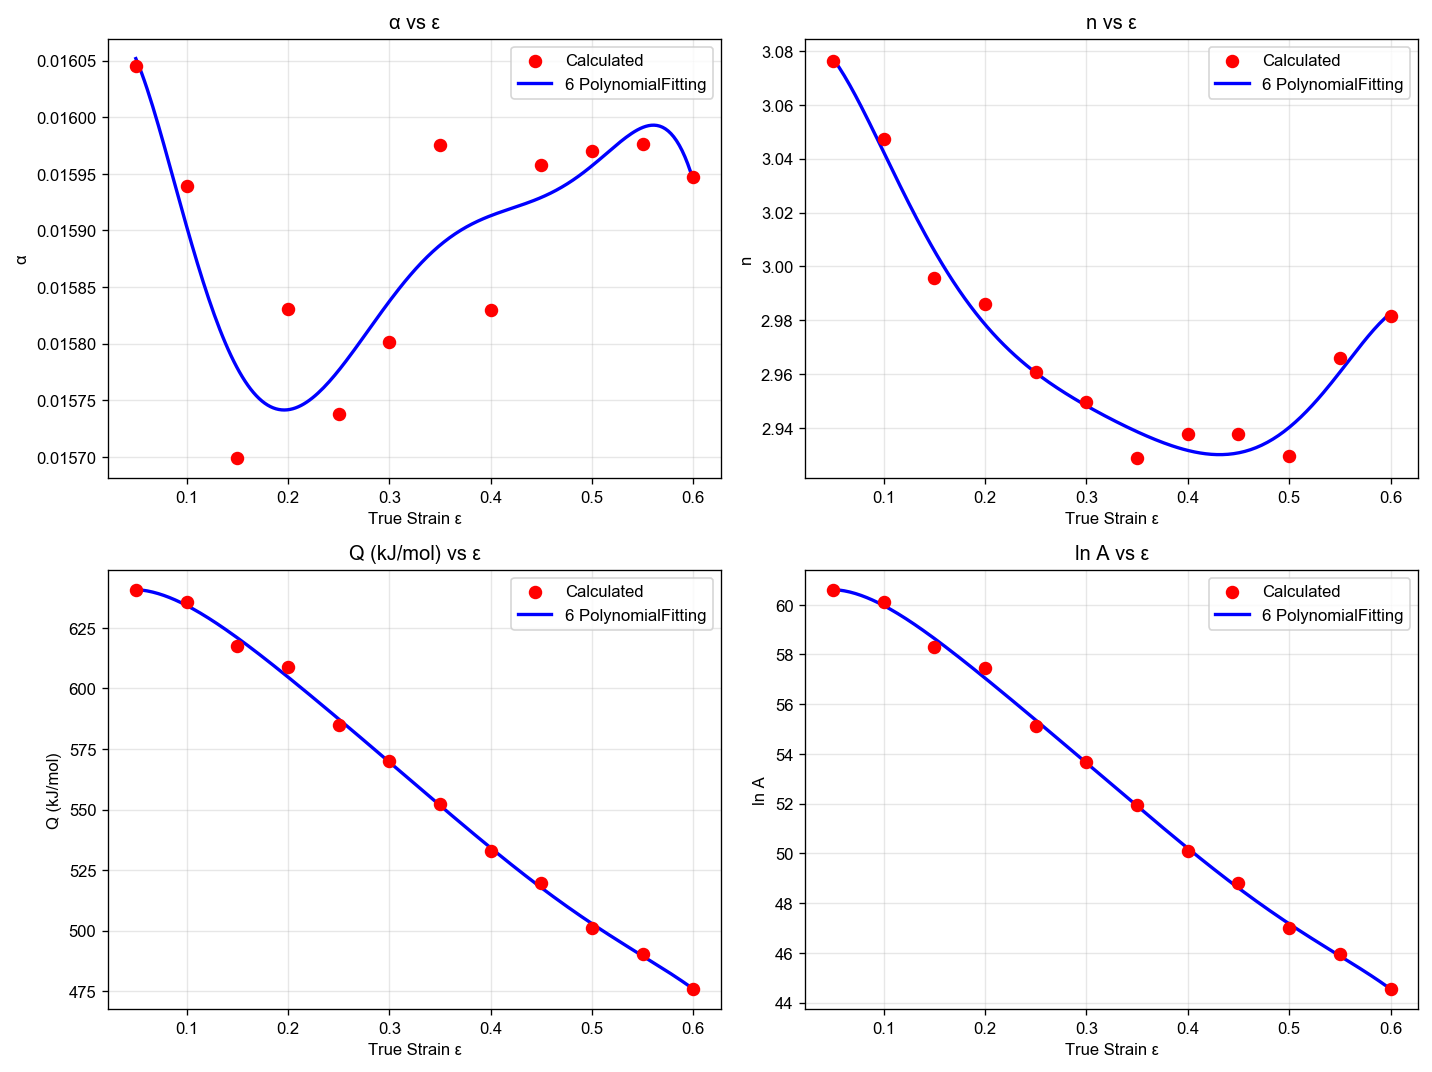

In [19]:
# 可视化多项式拟合效果
eps_fine = np.linspace(eps_arr.min(), eps_arr.max(), 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

param_names = ['α', 'n', 'Q (kJ/mol)', 'ln A']
param_data = [params_df['α'].values, params_df['n'].values,
              params_df['Q (kJ/mol)'].values, params_df['ln A'].values]
param_polys = [poly_alpha, poly_n, poly_Q, poly_lnA]
param_scales = [1, 1, 1/1000, 1]  # Q 需要从 J/mol 转为 kJ/mol 显示

for ax, name, data, poly, scale in zip(axes.flat, param_names, param_data, param_polys, param_scales):
    ax.scatter(eps_arr, data, c='red', s=50, zorder=5, label='计算值')
    fitted = np.polyval(poly, eps_fine) * scale
    ax.plot(eps_fine, fitted, 'b-', linewidth=2, label=f'{poly_degree}次多项式拟合')
    ax.set_xlabel('True Strain ε')
    ax.set_ylabel(name)
    ax.set_title(f'{name} vs ε')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 第四章：全曲线预测

$$\sigma = \frac{1}{\alpha(\varepsilon)} \ln \left\{ \left(\frac{Z}{A(\varepsilon)}\right)^{\frac{1}{n(\varepsilon)}} + \sqrt{ \left(\frac{Z}{A(\varepsilon)}\right)^{\frac{2}{n(\varepsilon)}} + 1 } \right\}$$

其中 $Z = \dot{\varepsilon} \exp\left( \frac{Q(\varepsilon)}{RT} \right)$

In [20]:
def predict_stress(epsilon, strain_rate, T_K, poly_alpha, poly_n, poly_Q, poly_lnA):
    """根据 Arrhenius 本构方程预测流变应力"""
    alpha = np.polyval(poly_alpha, epsilon)
    n_val = np.polyval(poly_n, epsilon)
    Q_val = np.polyval(poly_Q, epsilon)
    lnA = np.polyval(poly_lnA, epsilon)

    ln_Z = np.log(strain_rate) + Q_val / (R_GAS * T_K)
    # Z/A = exp(lnZ - lnA)
    ln_Z_over_A = ln_Z - lnA
    # (Z/A)^(1/n)
    x = np.exp(ln_Z_over_A / n_val)
    # σ = (1/α) * arcsinh(x) = (1/α) * ln(x + sqrt(x² + 1))
    sigma = (1.0 / alpha) * np.log(x + np.sqrt(x**2 + 1))
    return sigma

# 验证：在离散点处预测并与实验值对比
print('=== 模型预测 vs 实验值（离散应变点处） ===')
predictions = []
for _, row in df_discrete.iterrows():
    eps = row['真应变']
    if eps < eps_arr.min() or eps > eps_arr.max():
        continue
    sigma_pred = predict_stress(eps, row['应变速率'], row['温度_K'],
                                poly_alpha, poly_n, poly_Q, poly_lnA)
    if np.isfinite(sigma_pred) and sigma_pred > 0:
        predictions.append({
            '温度_C': row['温度_C'], '应变速率': row['应变速率'],
            '真应变': eps, '实验值': row['流变应力'],
            '预测值': sigma_pred, '误差%': abs(sigma_pred - row['流变应力']) / row['流变应力'] * 100
        })

pred_df = pd.DataFrame(predictions)
print(f'\n平均相对误差(AARE): {pred_df["误差%"].mean():.2f}%')
print(f'最大相对误差: {pred_df["误差%"].max():.2f}%')
print(f'相关系数 R: {np.corrcoef(pred_df["实验值"], pred_df["预测值"])[0,1]:.6f}')
print()
print('各条件下的预测对比（ε=0.3 处）：')
sample = pred_df[np.isclose(pred_df['真应变'], 0.3)]
print(sample[['温度_C', '应变速率', '实验值', '预测值', '误差%']].to_string(index=False))

=== 模型预测 vs 实验值（离散应变点处） ===

平均相对误差(AARE): 20.88%
最大相对误差: 93.93%
相关系数 R: 0.972826

各条件下的预测对比（ε=0.3 处）：
  温度_C   应变速率        实验值        预测值       误差%
 800.0  0.001  59.839577 116.046878 93.929978
 800.0  0.010 132.358095 164.090694 23.974808
 800.0  0.100 249.938141 213.128169 14.727633
 800.0  1.000 319.632155 262.383504 17.910792
 800.0 10.000 385.663732 311.684970 19.182193
 850.0  0.001  36.080707  62.835144 74.151644
 850.0  0.010  92.708340 105.169093 13.440811
 850.0  0.100 166.737595 152.687178  8.426664
 850.0  1.000 233.922586 201.604290 13.815808
 850.0 10.000 260.961854 250.833891  3.881013
 900.0  0.001  27.381327  29.447363  7.545419
 900.0  0.010  56.313388  58.104125  3.179949
 900.0  0.100 108.622017  99.282894  8.597818
 900.0  1.000 143.224206 146.430140  2.238402
 900.0 10.000 213.516953 195.260162  8.550511
 950.0  0.001  14.554985  13.480791  7.380246
 950.0  0.010  22.889203  28.666305 25.239417
 950.0  0.100  50.598172  56.795058 12.247252
 950.0  1.000  73.39577

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell22__fig01__Arrhenius_(_)vs_Experimental_Data(_)__20260306_005855.png


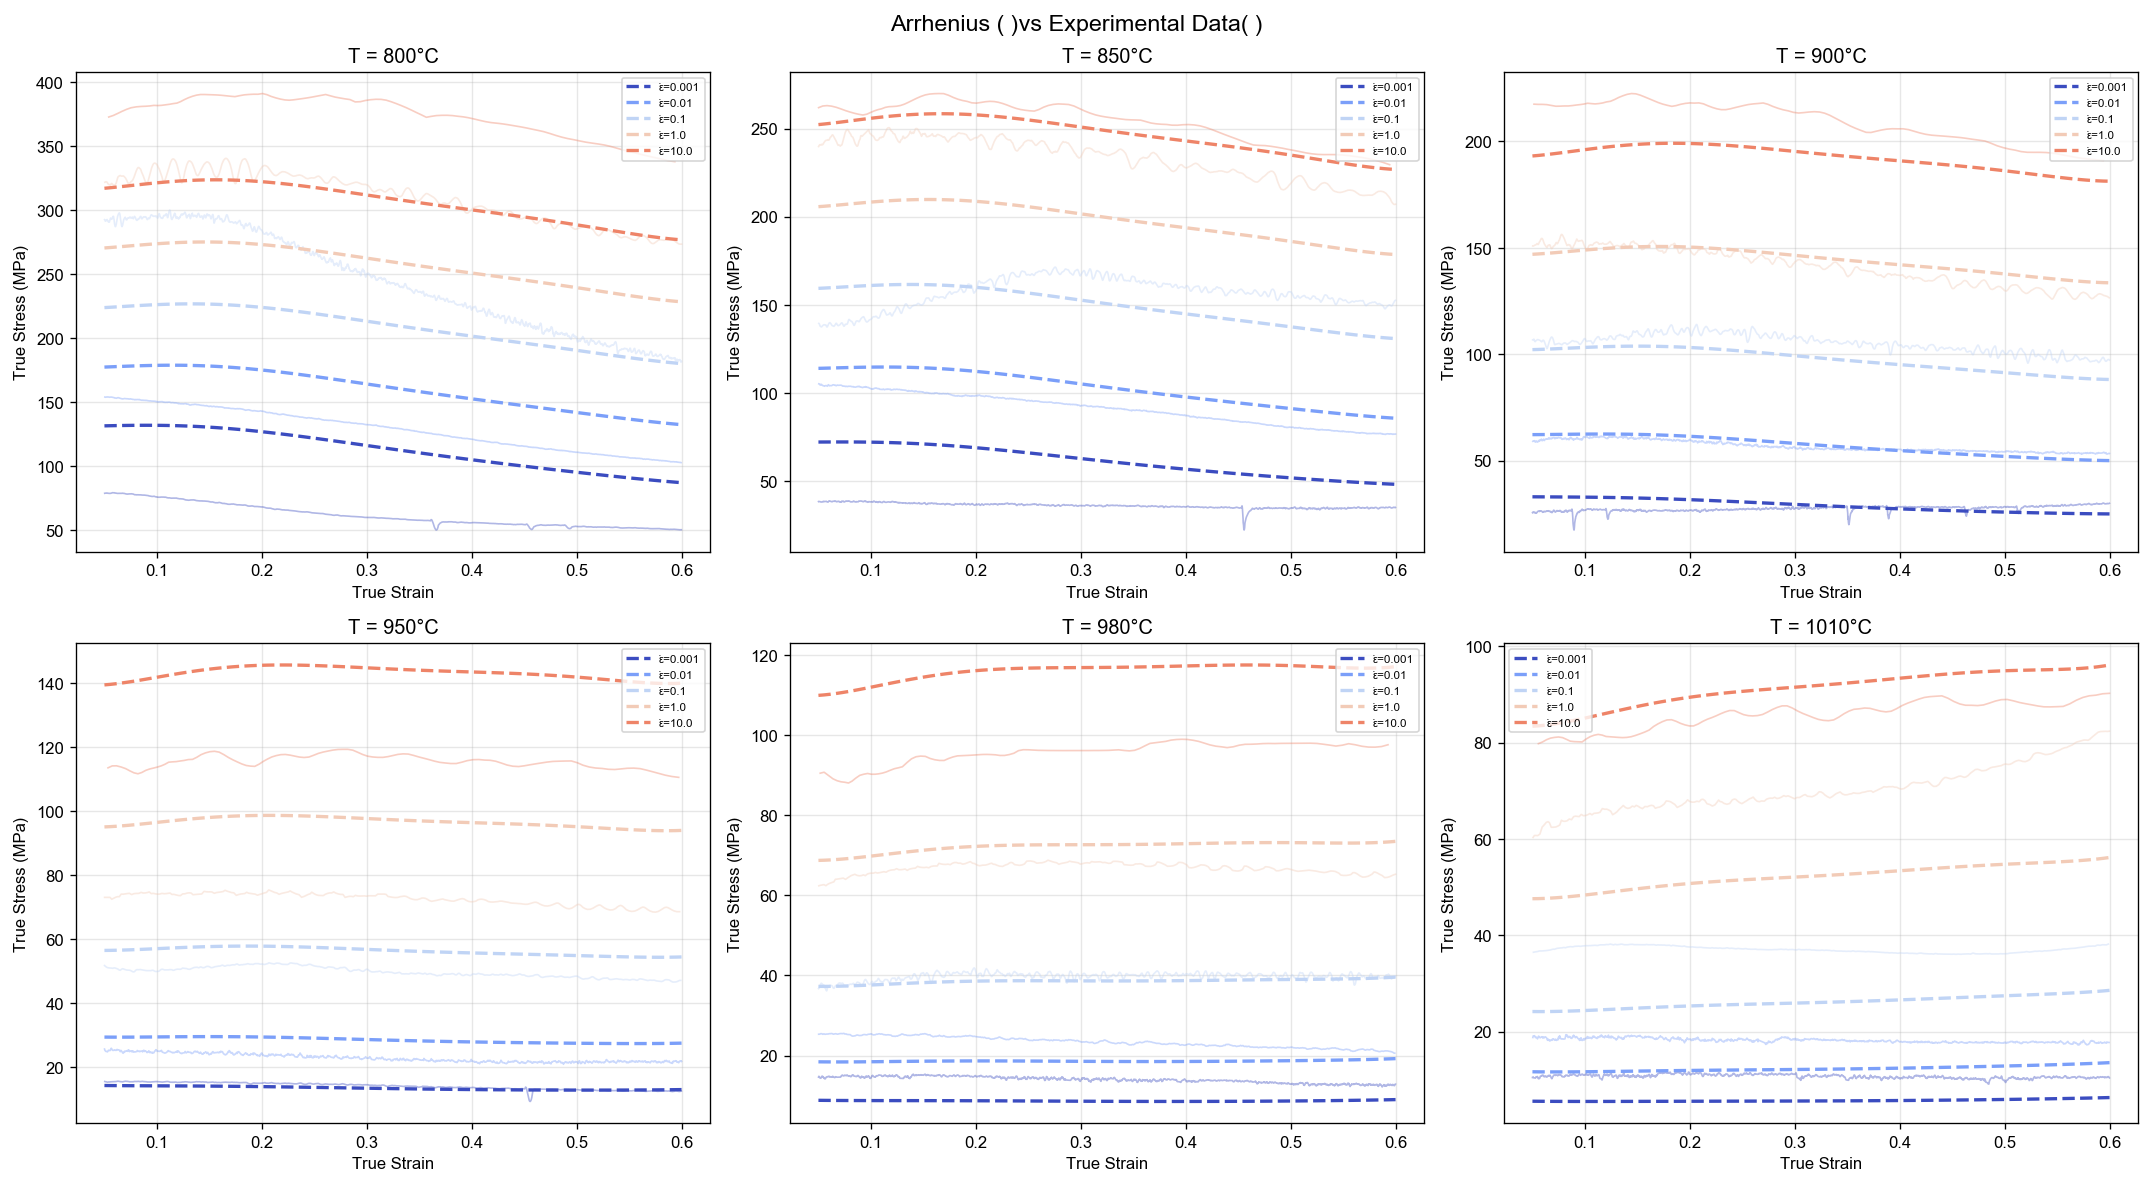

In [21]:
# 全曲线预测可视化
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
eps_pred = np.linspace(eps_arr.min(), eps_arr.max(), 100)

for ax, temp in zip(axes.flat, temps):
    for sr, c in zip(rates, rate_colors):
        # 实验数据
        exp = df_all[(df_all['温度_C'] == temp) & (df_all['应变速率'] == sr)].sort_values('真应变')
        exp = exp[(exp['真应变'] >= eps_arr.min()) & (exp['真应变'] <= eps_arr.max())]
        if len(exp) > 0:
            ax.plot(exp['真应变'], exp['流变应力'], '-', color=c, alpha=0.4, linewidth=1)

        # 预测曲线
        T_K = temp + 273.15
        sigma_pred = [predict_stress(e, sr, T_K, poly_alpha, poly_n, poly_Q, poly_lnA) for e in eps_pred]
        sigma_pred = np.array(sigma_pred)
        valid = np.isfinite(sigma_pred) & (sigma_pred > 0)
        if valid.sum() > 0:
            ax.plot(eps_pred[valid], sigma_pred[valid], '--', color=c, linewidth=2, label=f'ε̇={sr}')

    ax.set_title(f'T = {temp}°C')
    ax.set_xlabel('True Strain')
    ax.set_ylabel('True Stress (MPa)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Arrhenius ( )vs Experimental Data( )', fontsize=14)
plt.tight_layout()
plt.show()

✓ 已自动保存高清图片: /Users/bertonyang/project/chenglu/data_processor/arrhenius_calculation_figures/cell23__fig01__Arrhenius_Model_Accuracy_Evaluation__20260306_005901.png


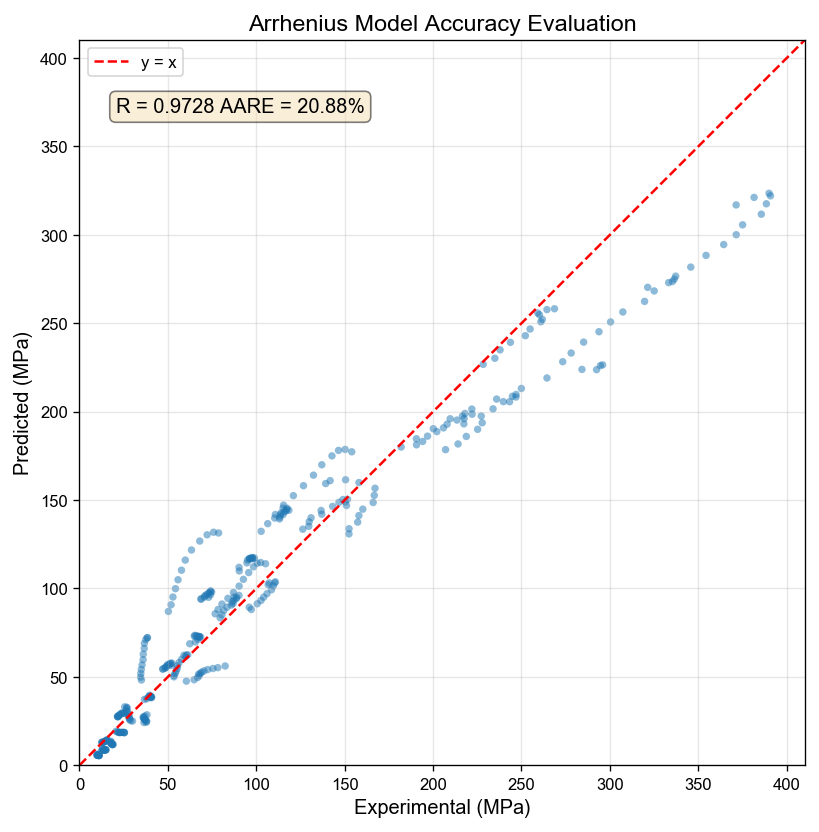


=== 模型评估指标 ===
相关系数 R: 0.972826
决定系数 R²: 0.946390
平均相对误差 AARE: 20.88%


In [22]:
# 预测值 vs 实验值散点图（评估模型精度）
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(pred_df['实验值'], pred_df['预测值'], alpha=0.5, s=20, edgecolors='none')

max_val = max(pred_df['实验值'].max(), pred_df['预测值'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='y = x')

R_val = np.corrcoef(pred_df['实验值'], pred_df['预测值'])[0, 1]
AARE = pred_df['误差%'].mean()
ax.text(0.05, 0.9, f'R = {R_val:.4f}\nAARE = {AARE:.2f}%',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Experimental (MPa)', fontsize=12)
ax.set_ylabel('Predicted (MPa)', fontsize=12)
ax.set_title('Arrhenius C', fontsize=14)
ax.legend()
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n=== 模型评估指标 ===')
print(f'相关系数 R: {R_val:.6f}')
print(f'决定系数 R²: {R_val**2:.6f}')
print(f'平均相对误差 AARE: {AARE:.2f}%')